In [56]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END,add_messages

# short term memory persistence
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.sqlite import SqliteStore

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
import os

llm = ChatOllama(model="qwen3:1.7b")
embeddings = OllamaEmbeddings(model="nomic-embed-text")

In [57]:
import os
import sqlite3

def embed_texts(texts: list[str]) -> list[list[float]]:
    return embeddings.embed_documents(texts)

os.makedirs('db',exist_ok=True)
db_path = "db/agent_data.db"

# 1. Create the context manager objects
saver_ctx = SqliteSaver.from_conn_string(db_path)
store_ctx = SqliteStore.from_conn_string(db_path)

# 2. Manually "Enter" them to get the actual objects
checkpointer = saver_ctx.__enter__()
store = store_ctx.__enter__()

In [58]:
user_id = "hoo"
namespace = (user_id,"preferences")

# Memory Operations: put(), get(), search(), delete()
store.put(namespace, "food", {"diet": "veg", 
                              "likes": ["pasta", "pizza", "veggies"]})


store.put(namespace, "color", {"favorite": "blue", 
                               "dislike": "brown"})

store.put(namespace, "work", {
    "role": "Data Scientist",
    "interests": ["machine learning", "ai", "gen ai", "agents"]
})

In [59]:
store.get(namespace, "color")

Item(namespace=['hoo', 'preferences'], key='color', value={'favorite': 'blue', 'dislike': 'brown'}, created_at='2026-03-02T02:13:11', updated_at='2026-03-02T02:13:11')

In [60]:
# Semantic Search

query = "What does hoo like to eat?"
results = store.search(namespace, query=query, limit=1)
results

[Item(namespace=['hoo', 'preferences'], key='food', value={'diet': 'veg', 'likes': ['pasta', 'pizza', 'veggies']}, created_at='2026-03-02T02:13:11', updated_at='2026-03-02T02:13:11', score=None)]

In [61]:
class AgentState(TypedDict):
    messages: Annotated[list,add_messages]
    user_id: str

@tool
def save_user_memory(user_id:str, category:str, information:dict) -> str:
    """
    Save user preference or information to long-term memory.

    Args:
        user_id: User identifier
        category: Category of information (e.g., 'food', 'work', 'hobbies', 'schedule', 'location','profile')
        information: Dictionary containing the information to save
    """

    namespace = (user_id, "preferences")

    store.put(namespace, category, information)

    return f"Saved {category} preferences."

@tool
def get_user_memory(user_id:str, category:str) -> str:
    """
        Retrieve user preference or information from long-term memory.

        Args:
            user_id: User identifier
            category: Category of information to retrieve (e.g., 'food', 'work', 'hobbies','profile')
        """
    
    namespace = (user_id, "preferences")

    item = store.get(namespace, category)

    if item:
        return f"{category}: {item.value}"
    else:
        return f"No '{category}' information found!"

def call_agent(state: AgentState):

    llm_with_tools = llm.bind_tools([save_user_memory, get_user_memory])
    user_id = state.get("user_id", "unknown")
    namespace = (user_id, "preferences")

    last_message = state['messages'][-1].content
    memories = store.search(namespace, query=last_message, limit=3)

    context = "\n\n".join([f" -{mem.key}: {mem.value}" for mem in memories]) if memories else "None"

    print(f"User Memory Retrieve: \n{context}\n")

    system_prompt = SystemMessage(f"""
                        You are a helpful assistant with long-term memory capabilities.

                            User ID: {user_id}
                            Current User Memories:
                            {context}

                            MEMORY TOOLS USAGE:

                            1. save_user_memory: Use when user shares NEW information
                            - Always pass user_id: "{user_id}"
                            - Food preferences (diet, likes, dislikes, allergies)
                            - Work information (role, company, interests)
                            - Hobbies and activities
                            - Schedule and availability
                            - Location and timezone

                            2. get_user_memory: Use when you need to recall specific category
                            - Always pass user_id: "{user_id}"
                            - When answering questions about past preferences
                            - When user asks "what do you know about me?"
                            - When making recommendations based on preferences

                            GUIDELINES:
                            - Always save when user shares personal information
                            - Retrieve specific categories when needed for context
                            - Use semantic search results shown above for general context
                        """)
    
    messages = [system_prompt] + state['messages']

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print(f"[AGENT] Responding...")

    return {'messages':[response]}

In [62]:
def should_continue(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    else:
        return END

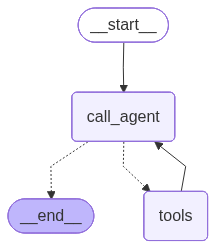

In [68]:
from langgraph.prebuilt import ToolNode

tools = [save_user_memory, get_user_memory]

builder = StateGraph(AgentState)
builder.add_node("call_agent", call_agent)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "call_agent")
builder.add_edge("tools", "call_agent")
builder.add_conditional_edges("call_agent", should_continue, ["tools", END])

graph = builder.compile(checkpointer=checkpointer,store=store)
graph

In [69]:
config_1 = {"configurable": {"thread_id": "T1"}}
input_1 = {"messages": [HumanMessage(content="My name is Hoo. Please save my name to my profile")], "user_id": "hoo"}
r1 = graph.invoke(input_1, config_1)
r1

User Memory Retrieve: 
 -profile: {'name': 'Hoo'}

 -food: {'diet': 'veg', 'likes': ['pasta', 'pizza', 'veggies']}

 -color: {'favorite': 'blue', 'dislike': 'brown'}

[AGENT] called Tool save_user_memory with args {'category': 'profile', 'information': {'name': 'Hoo'}, 'user_id': 'hoo'}
User Memory Retrieve: 
 -profile: {'name': 'Hoo'}

 -food: {'diet': 'veg', 'likes': ['pasta', 'pizza', 'veggies']}

 -color: {'favorite': 'blue', 'dislike': 'brown'}

[AGENT] Responding...


{'messages': [HumanMessage(content='Hi, im Hoo', additional_kwargs={}, response_metadata={}, id='315758f2-022c-4637-9872-a8b04999c08d'),
  HumanMessage(content='Hi, im Hoo', additional_kwargs={}, response_metadata={}, id='b9323265-865e-4129-a5bb-bfde05f40633'),
  HumanMessage(content='Hi, im Hoo', additional_kwargs={}, response_metadata={}, id='b7fa19cb-c725-46c7-940f-a6de773cae8e'),
  HumanMessage(content='Hi, im Hoo', additional_kwargs={}, response_metadata={}, id='cbc19594-0276-4053-9e35-ffbe6f7856b9'),
  HumanMessage(content='Hi, im Hoo', additional_kwargs={}, response_metadata={}, id='60f58ec9-d222-4d90-b066-1d1822258755'),
  AIMessage(content="Hello, Hoo! 😊 It's great to see you again. How can I assist you today? Based on your preferences, I can suggest vegan dishes like pasta or veggies, or maybe discuss machine learning topics if you're into AI! Let me know how I can help. 🌱💻", additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T02:08:18.47

In [70]:
config_2 = {"configurable": {"thread_id": "T2"}}
input_2 = {"messages": [HumanMessage(content="Do you know my name?")], "user_id": "hoo"}
r2 = graph.invoke(input_2, config_2)
r2

User Memory Retrieve: 
 -profile: {'name': 'Hoo'}

 -food: {'diet': 'veg', 'likes': ['pasta', 'pizza', 'veggies']}

 -color: {'favorite': 'blue', 'dislike': 'brown'}

[AGENT] Responding...


{'messages': [HumanMessage(content='Do you know my name', additional_kwargs={}, response_metadata={}, id='70e459a3-ca30-4263-91c3-0ea9d03aee61'),
  AIMessage(content="I don't have your name stored in my system. Would you like to share your name so I can better assist you? 😊", additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T02:09:09.9138799Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8742336500, 'load_duration': 313512100, 'prompt_eval_count': 288, 'prompt_eval_duration': 283958900, 'eval_count': 169, 'eval_duration': 7094526400, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac4e-56f0-7472-ba48-491e6b50317a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 288, 'output_tokens': 169, 'total_tokens': 457}),
  HumanMessage(content='Do you know which is my favorite food?', additional_kwargs={}, response_metadata={}, id='b3f3719f-ec99-4d69-877a-409efd5cc27c'),
  AIMess